 # CyclinB/Cdk1 (bistable switch)


**CyclinB / Cdk1 model** — a two-variable ODE system where oscillations emerge from the interaction between a bistable switch (Cdc25 vs Wee1) and slow CyclinB synthesis/degradation.



Required packages: `numpy`, `scipy`, `matplotlib`, `jitcdde`. If `jitcdde` is missing, run `pip install jitcdde` in a terminal.

In [1]:
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from scipy.signal import find_peaks
from jitcdde import jitcdde, y, t

---
## 1 CyclinB / Cdk1 oscillator: bistable switch + slow synthesis/degradation

Two variables:

- $c$ — total CyclinB concentration (nM)
- $a$ — active CyclinB / Cdk1 complex (nM)

ODE system:

$$\frac{dc}{dt} = k_s - \mathrm{Hill}_\text{deg}(a)\, c$$

$$\frac{da}{dt} = \mathrm{Hill}_\text{cdc25}(a)\,(c-a) - \mathrm{Hill}^{\downarrow}_\text{Wee1}(a)\, a + k_s - \mathrm{Hill}_\text{deg}(a)\, a$$

with the generalized Hill forms

$$\mathrm{Hill}(a) = \alpha + \frac{\beta\, a^n}{\mathrm{EC}_{50}^n + a^n}, \qquad \mathrm{Hill}^{\downarrow}(a) = \alpha + \frac{\beta\, \mathrm{EC}_{50}^n}{\mathrm{EC}_{50}^n + a^n}.$$

Cdc25 (activator) and Wee1 (inhibitor) together form a bistable switch on $a$; CyclinB synthesis $k_s$ and feedback-driven degradation drive $c$ slowly across the switch, producing relaxation oscillations.

### 1.1 Hill functions, parameters, and ODE system

`Hill` is the increasing form (Cdc25, degradation), `HillDec` the decreasing form (Wee1).

In [2]:
def Hill(params, x):
    return params.a + (params.b * x**params.n) / (params.EC50**params.n + x**params.n)


def HillDec(params, x):
    """Decreasing Hill function (used for Wee1)."""
    return params.a + (params.b * params.EC50**params.n) / (params.EC50**params.n + x**params.n)


k_s   = 1
deg   = SimpleNamespace(a=0.01, b=0.04, EC50=32, n=17)
cdc25 = SimpleNamespace(a=0.16,  b=0.8,    EC50=35, n=11)
Wee1  = SimpleNamespace(a=0.08,  b=0.4,    EC50=30, n=3.5)


def dc_dt(c, a, ks=None):
    if ks is None:
        ks = k_s
    return ks - Hill(deg, a) * c


def da_dt(c, a, ks=None):
    if ks is None:
        ks = k_s
    return Hill(cdc25, a) * (c - a) - HillDec(Wee1, a) * a + ks - Hill(deg, a) * a


def odes(t, y_vec, ks=k_s):
    c, a = y_vec
    return [dc_dt(c, a, ks), da_dt(c, a, ks)]

### 1.2 Helpers: steady-state finder and simulator

`find_a_ss` returns all of $da/dt = 0$ when $c$ is on its nullcline $c_\text{ss}(a) = k_s/\mathrm{Hill}_\text{deg}(a)$.

In [3]:
def find_a_ss(ks_val, a_lo=0.1, a_hi=54.9):
    """All roots of da/dt(c_ss(a), a) = 0 for a given k_s (with c_ss from dc/dt = 0).
    Returns the equilibria of the full 2D system as a function of k_s."""
    def f(a):
        c_ss = ks_val / Hill(deg, a)
        return da_dt(c_ss, a, ks_val)

    a_scan = np.linspace(a_lo, a_hi, 5000)
    f_scan = np.array([f(ai) for ai in a_scan])
    roots = []
    for i in range(len(a_scan) - 1):
        if np.isfinite(f_scan[i]) and np.isfinite(f_scan[i+1]) and f_scan[i] * f_scan[i+1] < 0:
            try:
                roots.append(brentq(f, a_scan[i], a_scan[i+1], xtol=1e-6))
            except ValueError:
                pass
    return sorted(roots)


def find_a_ss_of_c(c_val, ks_val=None, a_lo=0.01, a_hi=80.0, n_scan=4000):
    """All roots of da/dt = 0 at fixed c (treating c as a slow parameter).

    This is the proper bistable-switch S-curve: a* as a function of c, with the
    fast subsystem da/dt taken at frozen c. The full da/dt is used (including
    the small synthesis/degradation contributions on a)."""
    if ks_val is None:
        ks_val = k_s

    def f(a):
        return da_dt(c_val, a, ks_val)

    a_scan = np.linspace(a_lo, a_hi, n_scan)
    f_scan = np.array([f(ai) for ai in a_scan])
    roots = []
    for i in range(len(a_scan) - 1):
        if np.isfinite(f_scan[i]) and np.isfinite(f_scan[i+1]) and f_scan[i] * f_scan[i+1] < 0:
            try:
                roots.append(brentq(f, a_scan[i], a_scan[i+1], xtol=1e-8))
            except ValueError:
                pass
    return sorted(roots)


def run_sim(ks_val, y0, t_end=600):
    sol = solve_ivp(
        odes, (0, t_end), y0, args=(ks_val,),
        t_eval=np.linspace(0, t_end, 6000),
        method='RK45', rtol=1e-8, atol=1e-10
    )
    return sol

### 1.3 Functional response curves

Cdc25, Wee1, and degradation rates as functions of $a$, plus the net flux of the switch.

In [4]:
def plot_response_curves():
    """Figure 1 — Hill response curves and the Cdc25/Wee1 net flux."""
    a_arr = np.linspace(0, 55, 500)

    fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    fig1.suptitle('Functional response curves (Hill functions)')

    # Left: individual rates vs active CyclinB
    ax = axes1[0]
    ax.plot(a_arr, Hill(cdc25, a_arr),   color='steelblue', lw=2, label='Cdc25 (activation, Hill↑)')
    ax.plot(a_arr, HillDec(Wee1, a_arr), color='tomato',    lw=2, label='Wee1 (inhibition, Hill↓)')
    ax.plot(a_arr, Hill(deg, a_arr),     color='grey',      lw=2, ls='--', label='Degradation (Hill↑)')
    ax.axvline(cdc25.EC50, color='steelblue', lw=0.8, ls=':')
    ax.axvline(Wee1.EC50,  color='tomato',    lw=0.8, ls=':')
    ax.set_xlabel('active CyclinB a (nM)')
    ax.set_ylabel('rate (1/min)')
    ax.set_title('Individual functional response curves')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Right: net switch flux assuming representative c-a value
    c_minus_a = 20.0
    ax2 = axes1[1]
    flux_cdc25 = Hill(cdc25, a_arr) * c_minus_a
    flux_wee1  = HillDec(Wee1, a_arr) * a_arr
    net        = flux_cdc25 - flux_wee1
    ax2.plot(a_arr, flux_cdc25, color='steelblue', lw=2, label='Cdc25 flux (×(c−a))')
    ax2.plot(a_arr, flux_wee1,  color='tomato',    lw=2, label='Wee1 flux (×a)')
    ax2.plot(a_arr, net,        color='black',     lw=2, ls='--', label='net (Cdc25 − Wee1)')
    ax2.axhline(0, color='k', lw=0.6)
    ax2.set_xlabel('active CyclinB a (nM)')
    ax2.set_ylabel('flux (nM/min)')
    ax2.set_title(f'Net switch flux  [c−a = {c_minus_a} nM fixed]')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)
    plt.show()
    return fig1

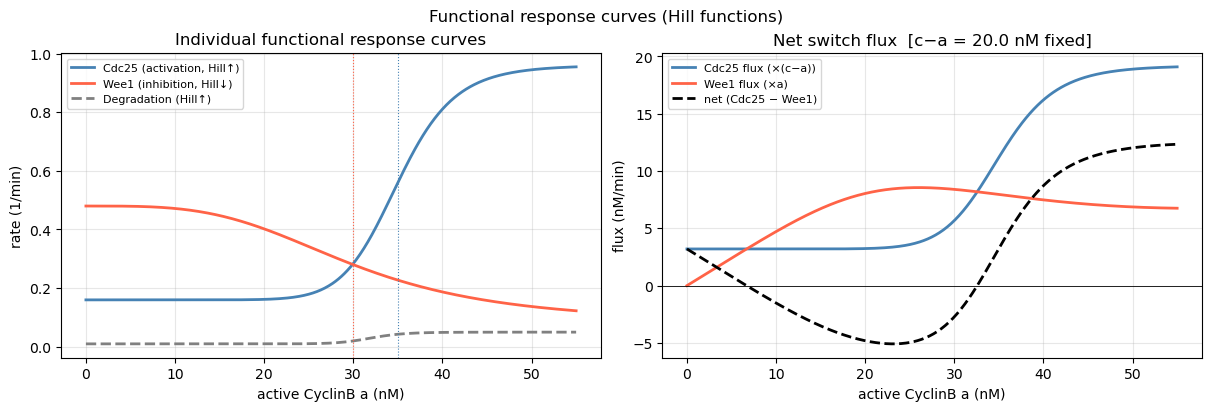

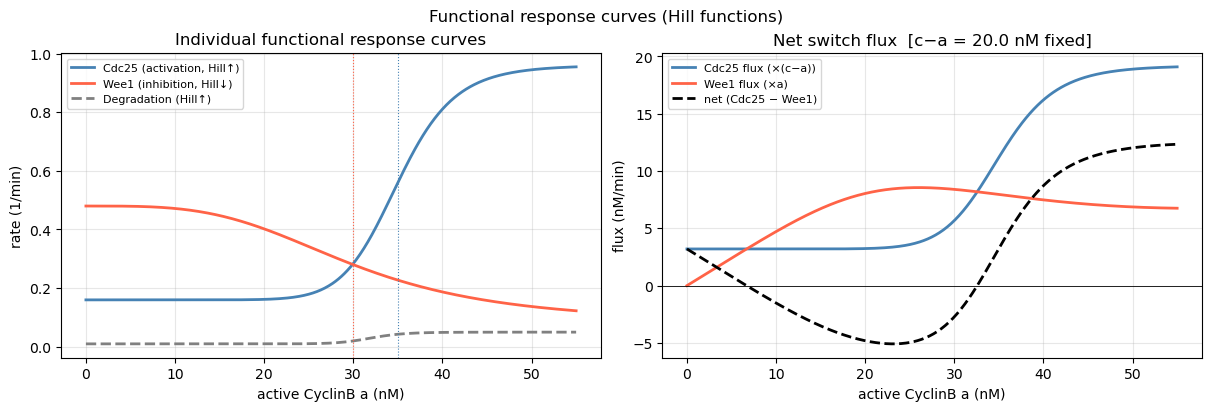

In [5]:
plot_response_curves()

### 1.4 Time series


In [6]:
def plot_time_series(ks_val=k_s, y0=(55.0, 25.0), t_end=600):
    """Figure 2 — c(t) and a(t)."""
    sol = run_sim(ks_val, list(y0), t_end=t_end)
    c_t, a_t = sol.y

    fig2, ax = plt.subplots(figsize=(8, 4))
    ax.plot(sol.t, c_t, label='c (total CyclinB)')
    ax.plot(sol.t, a_t, label='a (active CyclinB)')
    ax.set_xlabel('t (min)')
    ax.set_ylabel('concentration (nM)')
    ax.set_title(f'Cdk/Cyclin oscillator — time series  (k_s = {ks_val} nM/min)')
    ax.legend()
    ax.grid(alpha=0.3)
    fig2.tight_layout()
    plt.show()
    return sol

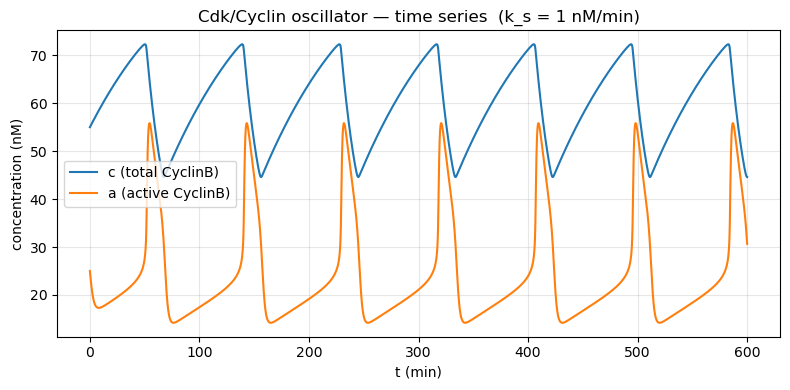

In [7]:
sol = plot_time_series()

### 1.5 Phase portrait

Nullclines, vector field, and the limit cycle in the $(c, a)$ plane. The flow $(\dot c, \dot a)$ is rendered as **streamlines** (colour and line width encode the local speed): from any starting point in the plane one can read off the direction in which the trajectories are pushed, making it clear that they all spiral onto the limit cycle.

In [8]:
def _a_nullcline_branches(c_array, ks_val=None):
    """Compute the a-nullcline split into low/mid/high branches over a range of c."""
    if ks_val is None:
        ks_val = k_s
    low, mid, high = [], [], []
    for c_val in c_array:
        roots = find_a_ss_of_c(c_val, ks_val=ks_val)
        if len(roots) >= 3:
            low.append( (c_val, roots[0]))
            mid.append( (c_val, roots[1]))
            high.append((c_val, roots[-1]))
        elif len(roots) == 2:
            low.append( (c_val, roots[0]))
            high.append((c_val, roots[-1]))
        elif len(roots) == 1:
            (low if roots[0] < 25 else high).append((c_val, roots[0]))
    return low, mid, high


def plot_phase_portrait(sol, c_range=(0, 100), a_range=(0, 80), n_arrows=22):
    """Figure 3 — phase portrait with a quiver vector field, nullclines and limit cycle.

    The a-nullcline is split by stability: blue = stable low, hashed = unstable middle,
    red = stable high. Quiver arrows at a coarse grid show the instantaneous direction
    of (dc/dt, da/dt): because a is the fast variable, arrows point predominantly
    vertically toward the a-nullcline."""
    from matplotlib.lines import Line2D

    c_t, a_t = sol.y

    # Coarse grid for the quiver
    c_q = np.linspace(c_range[0], c_range[1], n_arrows)
    a_q = np.linspace(a_range[0], a_range[1], n_arrows)
    Cq, Aq = np.meshgrid(c_q, a_q)
    dCq = np.asarray(dc_dt(Cq, Aq), dtype=float)
    dAq = np.asarray(da_dt(Cq, Aq), dtype=float)
    speed_q = np.sqrt(dCq**2 + dAq**2)
    eps = 1e-12
    U = dCq / (speed_q + eps)
    V = dAq / (speed_q + eps)

    fig3, ax = plt.subplots(figsize=(7.5, 6))

    q = ax.quiver(
        Cq, Aq, U, V, np.log10(speed_q + eps),
        cmap='inferno', pivot='mid', scale=35, width=0.0035, headwidth=4, alpha=0.85,
    )
    fig3.colorbar(q, ax=ax, label=r'$\log_{10}|(\dot c,\dot a)|$', pad=0.02)

    # c-nullcline (dense grid, contour)
    c_dense = np.linspace(c_range[0], c_range[1], 300)
    a_dense = np.linspace(a_range[0], a_range[1], 300)
    Cd, Ad = np.meshgrid(c_dense, a_dense)
    dCd = np.asarray(dc_dt(Cd, Ad), dtype=float)
    ax.contour(Cd, Ad, dCd, levels=[0], colors='deepskyblue', linewidths=2, linestyles='--')

    # a-nullcline split into branches by stability
    c_branch = np.linspace(max(c_range[0], 1e-3), c_range[1], 500)
    low, mid, high = _a_nullcline_branches(c_branch)
    if low:
        cl, al = zip(*low);  ax.plot(cl, al, color='royalblue', lw=2.6)
    if high:
        ch, ah = zip(*high); ax.plot(ch, ah, color='red',       lw=2.6)
    if mid:
        cm, am = zip(*mid);  ax.plot(cm, am, color='black', lw=2.2, ls=(0, (3, 3)))

    # Reference line a = c
    a_eq_c = np.linspace(max(c_range[0], a_range[0]), min(c_range[1], a_range[1]), 50)
    ax.plot(a_eq_c, a_eq_c, color='grey', lw=0.8, ls=':', alpha=0.7)

    # Limit cycle (skip transient)
    skip = len(sol.t) // 3
    ax.plot(c_t[skip:], a_t[skip:], color='black', lw=2.0, label='limit cycle')
    ax.plot(c_t[0], a_t[0], 'o', mfc='yellow', mec='black', mew=1.2, ms=8, zorder=5,
            label='initial condition')

    legend_elements = [
        Line2D([0], [0], color='deepskyblue', lw=2, ls='--', label=r'$\dot c = 0$'),
        Line2D([0], [0], color='royalblue',   lw=2.6,         label=r'$\dot a = 0$ (stable low)'),
        Line2D([0], [0], color='black',       lw=2.2, ls=(0, (3, 3)), label=r'$\dot a = 0$ (unstable)'),
        Line2D([0], [0], color='red',         lw=2.6,         label=r'$\dot a = 0$ (stable high)'),
        Line2D([0], [0], color='black',       lw=2.0,         label='limit cycle'),
        Line2D([0], [0], color='grey',        lw=0.8, ls=':', label='a = c'),
        Line2D([0], [0], marker='o', color='w', mfc='yellow', mec='black', ms=8,
               label='initial condition'),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc='upper left', framealpha=0.9)

    ax.set_xlim(c_range)
    ax.set_ylim(a_range)
    ax.set_xlabel('c (nM)')
    ax.set_ylabel('a (nM)')
    ax.set_title('Phase portrait — vector field, nullclines and limit cycle')
    fig3.tight_layout()
    plt.show()
    return fig3

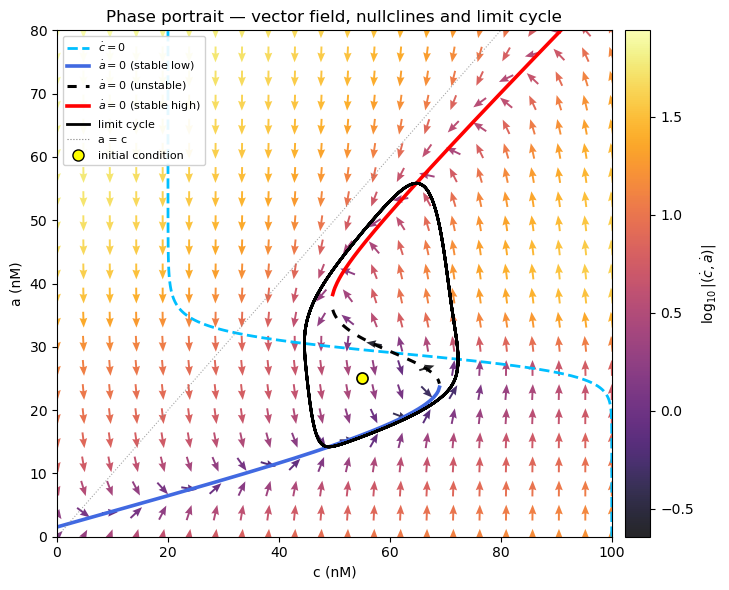

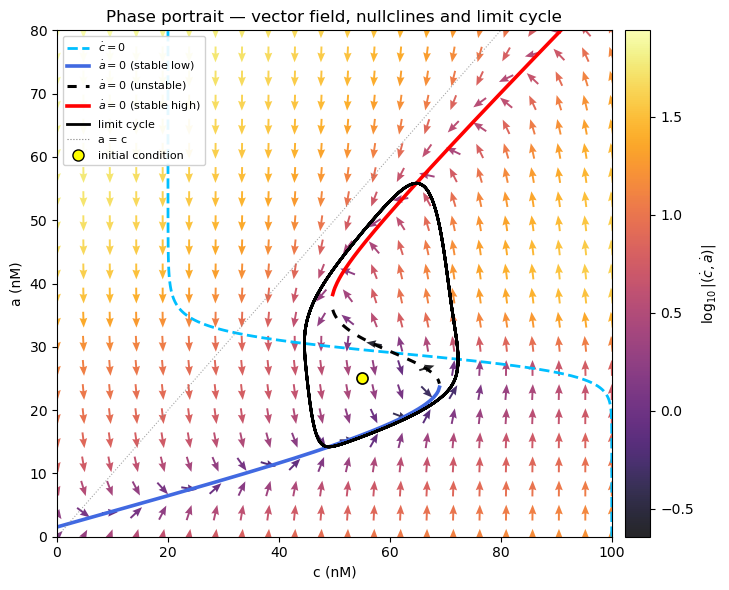

In [9]:
plot_phase_portrait(sol)

### 1.6 Hysteresis loop with $k_s$ sweep

Different from the switch S-curve (already visible in the phase portrait): here we treat $k_s$ as a **controllable external parameter** and probe the full 2D system. Procedure: pick a starting $k_s$, integrate to attractor, save the final state; increase $k_s$ slightly, use the saved state as initial condition, integrate, save, and so on. Repeat in reverse for the backward sweep.

- It matches the experimental protocol used to demonstrate Cdk1/CyclinB hysteresis in *Xenopus* extracts (Pomerening, Sible & Ferrell, 2003), so the figure connects the model to data.

In [10]:
def sweep_hysteresis(ks_vals, y0_start, t_end=300):
    """Quasi-static sweep over k_s: at each step the final state is reused as IC.
    Returns the final a (or mean of last peaks if oscillating)."""
    a_tracked = []
    y_state = list(y0_start)
    for ks_val in ks_vals:
        sol_h = run_sim(ks_val, y_state, t_end=t_end)
        y_state = [sol_h.y[0, -1], sol_h.y[1, -1]]
        peaks, _ = find_peaks(sol_h.y[1])
        if len(peaks) >= 4:
            a_tracked.append(np.mean(sol_h.y[1, peaks[-4:]]))
        else:
            a_tracked.append(sol_h.y[1, -1])
    return np.array(a_tracked)


def plot_hysteresis_ks(ks_min=0.3, ks_max=4.0, num_sweep=80, a_max=80):
    """Figure 4 — hysteresis of the full 2D system under a quasi-static k_s sweep.

    Forward sweep (low → high k_s) and backward sweep (high → low k_s) following
    the system's attractor. Different jump points reveal coexistence of attractors
    and locate global bifurcations in k_s — directly comparable to experimental
    hysteresis protocols (e.g. Pomerening, Sible, Ferrell 2003)."""
    ks_fwd = np.linspace(ks_min, ks_max, num_sweep)
    ks_bwd = ks_fwd[::-1]
    a_fwd = sweep_hysteresis(ks_fwd, [20.0, 5.0])
    a_bwd = sweep_hysteresis(ks_bwd, [70.0, 50.0])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ks_fwd, a_fwd, 'b-o', ms=3.5, lw=1.5, label='forward sweep (low → high k_s)')
    ax.plot(ks_bwd, a_bwd, 'r-o', ms=3.5, lw=1.5, label='backward sweep (high → low k_s)')
    ax.axvline(k_s, color='green', lw=1.2, ls=':', label=f'k_s = {k_s}')
    ax.set_xlabel('synthesis rate k_s (nM/min)')
    ax.set_ylabel('a (nM) after transient')
    ax.set_title('Hysteresis loop of the full 2D system under quasi-static k_s sweep')
    ax.set_xlim(ks_min, ks_max)
    ax.set_ylim(0, a_max)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig

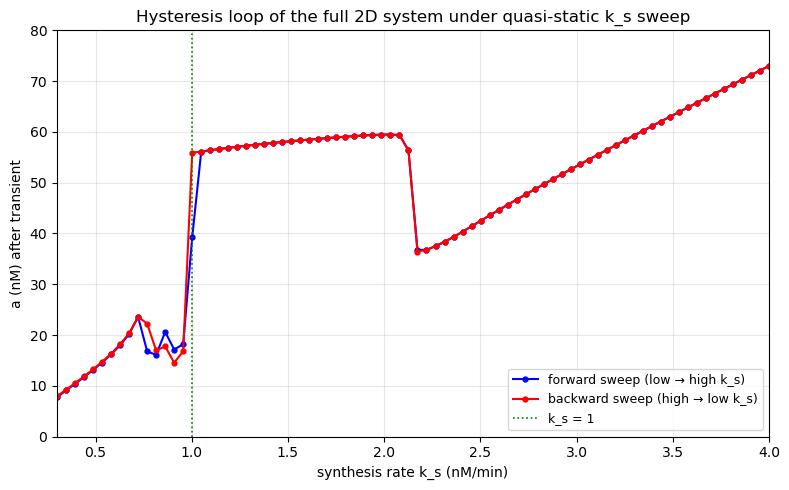

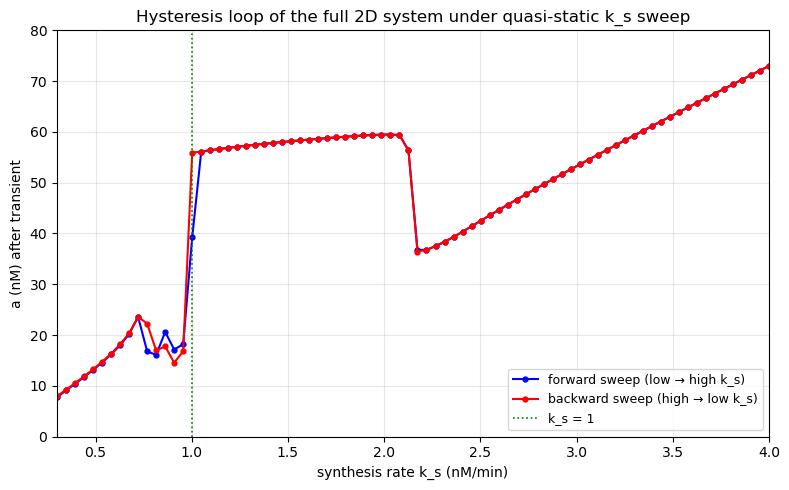

In [11]:
plot_hysteresis_ks()

## 1.7 Period and amplitude vs $k_s$

In [12]:
def plot_period_amplitude(ks_min=0.3, ks_max=4.0, num=60):
    """Figure 6 — period and amplitude of oscillation vs k_s."""
    ks_osc = np.linspace(ks_min, ks_max, num)
    periods, amplitudes = [], []

    for ks_val in ks_osc:
        sol_o = run_sim(ks_val, [55.0, 25.0], t_end=800)
        a_sig = sol_o.y[1]
        t_sig = sol_o.t
        half = len(t_sig) // 2
        peaks, _ = find_peaks(a_sig[half:], prominence=2)
        troughs, _ = find_peaks(-a_sig[half:], prominence=2)
        if len(peaks) >= 2:
            dt_arr = np.diff(t_sig[half:][peaks])
            periods.append(np.mean(dt_arr))
            amp = np.mean(a_sig[half:][peaks]) - np.mean(a_sig[half:][troughs]) if len(troughs) >= 1 else np.nan
            amplitudes.append(amp)
        else:
            periods.append(np.nan)
            amplitudes.append(np.nan)

    periods    = np.array(periods)
    amplitudes = np.array(amplitudes)
    osc_mask   = np.isfinite(periods)

    fig6, axes6 = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    fig6.suptitle('Oscillation properties vs synthesis rate k_s')

    axes6[0].plot(ks_osc[osc_mask], periods[osc_mask], 'ko-', ms=4, lw=1.5)
    axes6[0].axvline(k_s, color='green', lw=1.2, ls=':', label=f'k_s = {k_s}')
    axes6[0].set_xlabel('k_s (nM/min)')
    axes6[0].set_ylabel('period (min)')
    axes6[0].set_title('Oscillation period')
    axes6[0].set_xlim(ks_min, ks_max)
    axes6[0].legend(fontsize=8)
    axes6[0].grid(alpha=0.3)

    axes6[1].plot(ks_osc[osc_mask], amplitudes[osc_mask], 'ko-', ms=4, lw=1.5)
    axes6[1].axvline(k_s, color='green', lw=1.2, ls=':', label=f'k_s = {k_s}')
    axes6[1].set_xlabel('k_s (nM/min)')
    axes6[1].set_ylabel('amplitude (nM)')
    axes6[1].set_title('Oscillation amplitude')
    axes6[1].set_xlim(ks_min, ks_max)
    axes6[1].legend(fontsize=8)
    axes6[1].grid(alpha=0.3)
    plt.show()
    return fig6

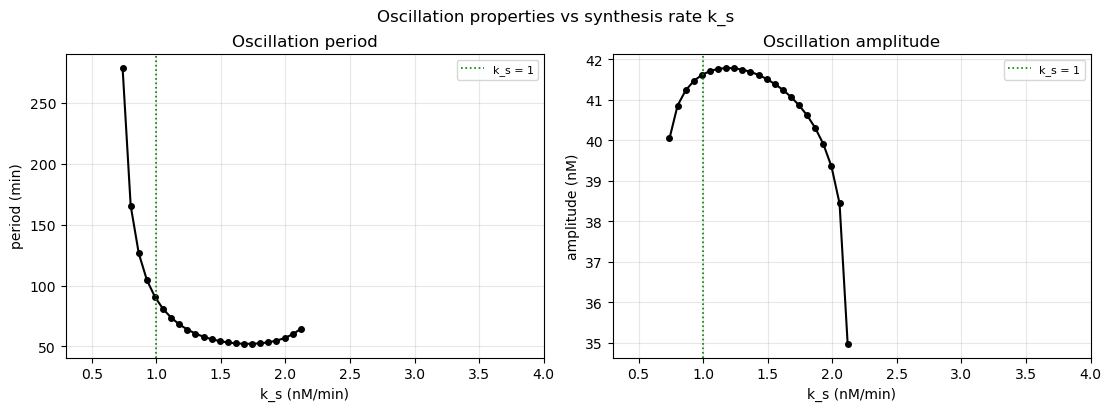

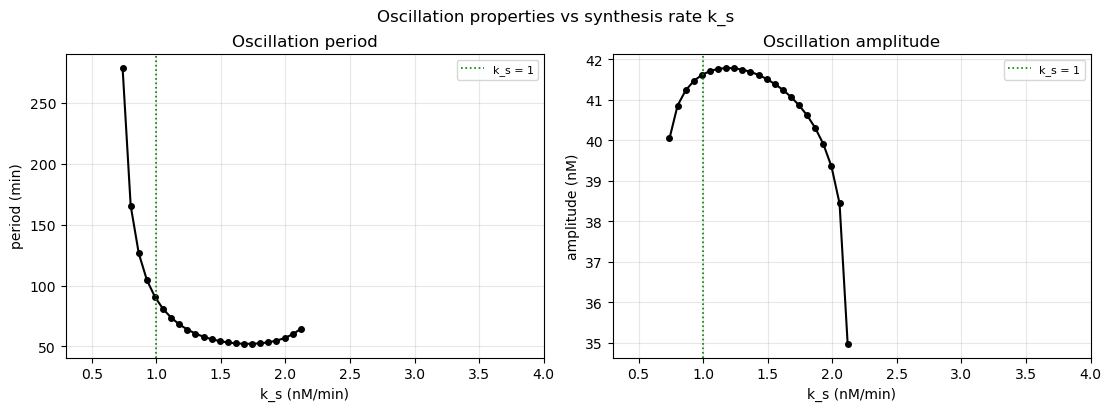

In [13]:
plot_period_amplitude()